# Price Momentum Factor Analysis

## Research Objective
This notebook evaluates the predictive value and persistence of the price momentum factor in the A-share equity universe.


## Factor Definition
The price momentum factor is measured as cumulative stock return over a fixed historical lookback window. It is intended to capture medium-term trend persistence in stock prices.

## Research Hypothesis
The working hypothesis is that stocks with stronger medium-term momentum tend to continue outperforming over the next holding period, provided the signal is not already excessively overextended.

## Data and Test Design
The factor is evaluated through grouped return analysis, cumulative performance comparison by quantile, and monotonicity inspection of cross-sectional buckets.


Initiating Momentum Strategy Diagnostic...
Processing Snapshot: 2026-03-31

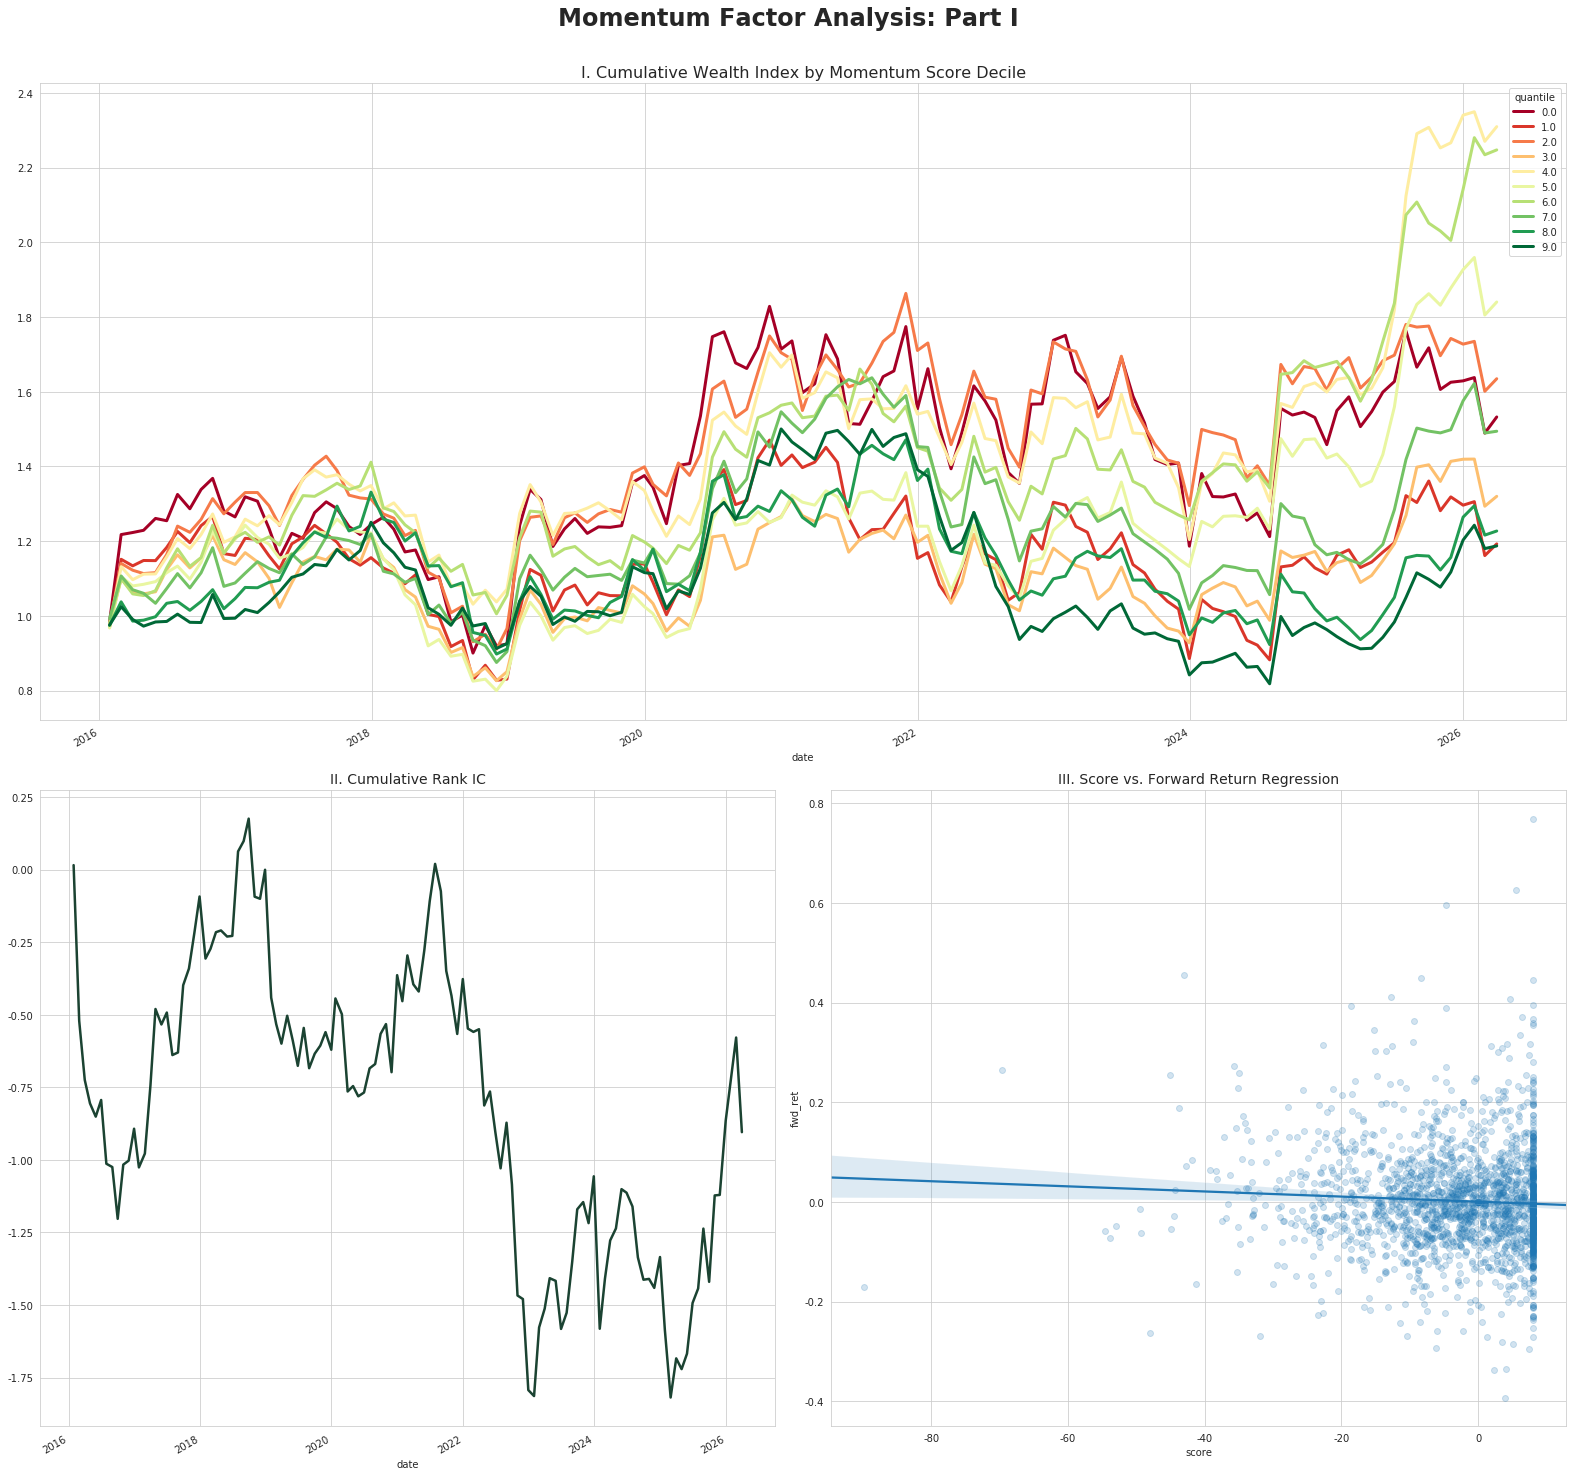

In [ ]:
'''
This factor is constructed based on the "Price Momentum" logic, 
aiming to capture "Winner-Takes-All" trend opportunities in the A-share market. 

By calculating scores based on the cross-sectional relative strength of individual stocks 
within a specific lookback period, this factor accurately identifies leading securities 
across different market phases, serving as the core source of strategic aggressiveness. 

While momentum factors exhibit high return explosive power during clear bull markets 
or trending environments, they are inherently "High Beta." They often display 
significant volatility during sharp market style rotations or "V-shape" reversals. 

This report provides a comprehensive "health check" of the factor, 
analyzing its score distribution across different years and the risk exposure of each decile. 
The goal is to provide a quantitative foundation for future "Dynamic Rebalancing" 
and "Drawdown Management" based on evolving market conditions.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
import warnings

# 1. Environment Configuration
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 2. Score Mapping Function 
def calculate_range_score(value, optimal_range, max_score, reverse=False):
    low, high = optimal_range
    if reverse:
        if value <= low: 
            return max_score
        elif value >= high: 
            return max_score * 0.1
        else: 
            return max_score * (1 - (value - low) / (high - low))
    else:
        if low <= value <= high: 
            return max_score
        elif value < low:
            # Penalize for insufficient momentum
            return max_score * (value / low) if low > 0 else max_score * 0.3
        else:
            # Penalize for excessive "chasing" risk (Mean Reversion)
            return max_score * (high / value) if value > 0 else max_score * 0.3

# 3. Parameters and Backtest Engine
start_date, end_date = "2016-01-01", "2026-04-01"
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

# Simulation Configuration
period = 20      # 20-day lookback period (approx. 1 month)
opt_range = (0.05, 0.15)
weight = 8

dataset = []
print("Initiating Momentum Strategy Diagnostic...")

for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i+1]
    universe = get_index_stocks('000300.XSHG', date=t0)
    print("\rProcessing Snapshot: {}".format(t0), end="")
    
    # Get closing prices to calculate momentum
    prices = get_price(universe, end_date=t0, count=period+1, fields='close', panel=False)
    
    res = []
    for s in universe:
        s_p = prices[prices['code'] == s]['close']
        if len(s_p) < period: 
            continue
        # Calculate raw momentum: (P_now / P_start) - 1
        raw_mom = (s_p.iloc[-1] / s_p.iloc[0] - 1)
        score = calculate_range_score(raw_mom, opt_range, weight)
        res.append({'code': s, 'raw': raw_mom, 'score': score})
    
    df = pd.DataFrame(res)
    # Fetch price data for the forward period (t0 to t1)
    p0 = get_price(list(df['code']), end_date=t0, count=1, fields='close', panel=False).set_index('code')['close']
    p1 = get_price(list(df['code']), end_date=t1, count=1, fields='close', panel=False).set_index('code')['close']
    
    df['fwd_ret'] = df['code'].map((p1 / p0) - 1)
    df['date'] = pd.to_datetime(t0)
    dataset.append(df)

# Consolidate results
master_df = pd.concat(dataset, ignore_index=True).dropna()
master_df['year'] = master_df['date'].dt.year
# Decile grouping based on scores
master_df['quantile'] = master_df.groupby('date')['score'].transform(
    lambda x: pd.qcut(x.rank(method='first'), 10, labels=False)
)

# 4. Visualization Part I
ic_ts = master_df.groupby('date').apply(lambda g: g['score'].corr(g['fwd_ret']))
q_ret = master_df.groupby(['date', 'quantile'])['fwd_ret'].mean().unstack()

fig1 = plt.figure(figsize=(22, 22))
plt.suptitle('Momentum Factor Analysis: Part I', fontsize=24, fontweight='bold', y=0.96)

# Plot I: Cumulative Wealth
ax1 = plt.subplot(2, 1, 1)
(1 + q_ret).cumprod().plot(ax=ax1, colormap='RdYlGn', lw=3)
ax1.set_title("I. Cumulative Wealth Index by Momentum Score Decile", fontsize=16)
ax1.set_xlabel("Rebalance Date")
ax1.set_ylabel("Wealth Index")

# Plot II: Cumulative Rank IC
ax2 = plt.subplot(2, 2, 3)
ic_ts.cumsum().plot(ax=ax2, color='#1b4332', lw=2.5)
ax2.set_title("II. Cumulative Rank IC (Momentum Persistence)", fontsize=14)
ax2.set_xlabel("Date")

# Plot III: Regression analysis
ax3 = plt.subplot(2, 2, 4)
sns.regplot(x='score', y='fwd_ret', data=master_df.sample(2000), ax=ax3, scatter_kws={'alpha':0.2})
ax3.set_title("III. Score vs. Forward Return (Regression)", fontsize=14)
ax3.set_xlabel("Factor Score")
ax3.set_ylabel("Next Month Return")

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

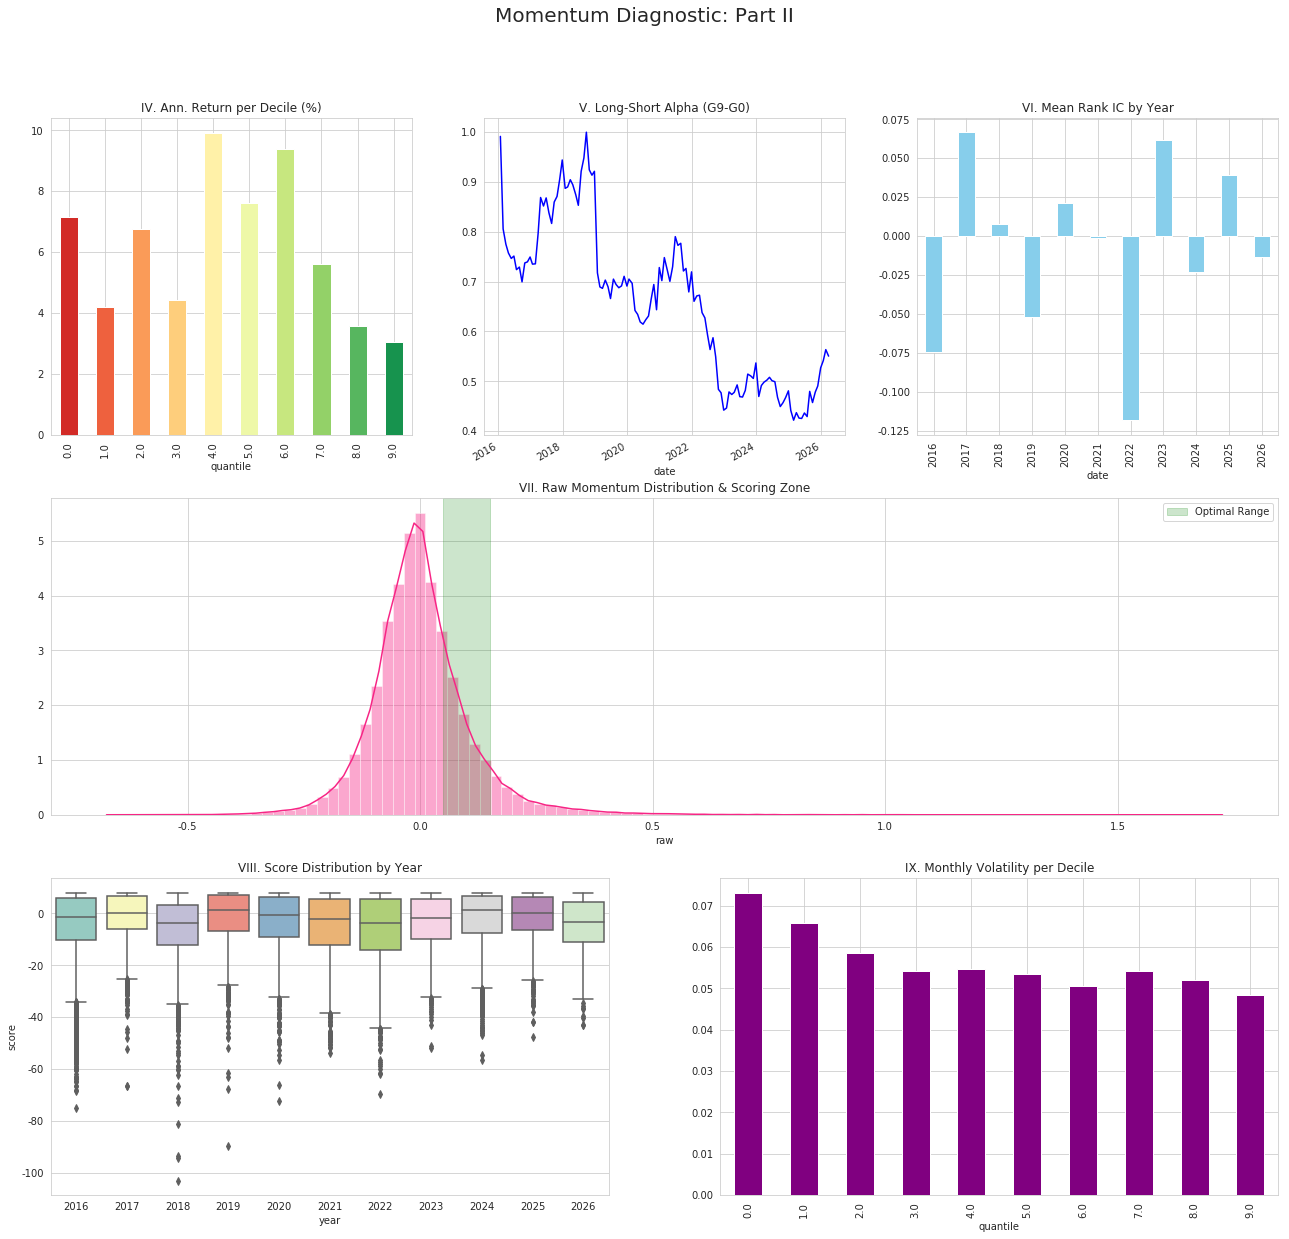

Avg IC: -0.0074 | G9 Ann. Return: 3.04%


In [ ]:
# ------------------------------------------------------------
# PART 2: STRATEGIC ATTRIBUTION (Compatibility Fix)
# ------------------------------------------------------------
fig2 = plt.figure(figsize=(22, 22))
plt.suptitle('Momentum Diagnostic: Part II', fontsize=20, y=0.95)

# IV. Annualized Return
ax4 = plt.subplot(3, 3, 1)
(q_ret.mean() * 12 * 100).plot(kind='bar', color=sns.color_palette("RdYlGn", 10), ax=ax4)
ax4.set_title("IV. Ann. Return per Decile (%)")

# V. Long-Short Alpha
ax5 = plt.subplot(3, 3, 2)
ls_ret = q_ret[9] - q_ret[0]
(1 + ls_ret).cumprod().plot(ax=ax5, color='blue')
ax5.set_title("V. Long-Short Alpha (G9-G0)")

# VI. Mean IC by Year
ax6 = plt.subplot(3, 3, 3)
ic_ts.groupby(ic_ts.index.year).mean().plot(kind='bar', color='skyblue', ax=ax6)
ax6.set_title("VI. Mean Rank IC by Year")

# VII. Raw Value Distribution 
ax7 = plt.subplot(3, 1, 2)

sns.distplot(master_df['raw'], bins=100, color='#f72585', ax=ax7)
ax7.axvspan(opt_range[0], opt_range[1], color='green', alpha=0.2, label='Optimal Range')
ax7.set_title("VII. Raw Momentum Distribution & Scoring Zone")
ax7.legend()

# VIII. Boxplot
ax8 = plt.subplot(3, 2, 5)
sns.boxplot(x='year', y='score', data=master_df, palette='Set3', ax=ax8)
ax8.set_title("VIII. Score Distribution by Year")

# IX. Volatility
ax9 = plt.subplot(3, 2, 6)
q_ret.std().plot(kind='bar', color='purple', ax=ax9)
ax9.set_title("IX. Monthly Volatility per Decile")

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

print("Avg IC: {:.4f} | G9 Ann. Return: {:.2f}%".format(ic_ts.mean(), q_ret[9].mean()*12*100))